# Fifty-Two-Week-High — momentum signal or mega-cap mirage?
### Ranking S&P 500 names by proximity to their 52-week high, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![George--Hwang: Inverted_on_Large-Caps](https://img.shields.io/badge/George--Hwang-Inverted__on__Large--Caps-8b949e?style=flat-square)

Here is one of the most cited momentum strategies in academic finance: buy stocks that are near their 52-week high. The logic is anchoring psychology — investors are reluctant to pay more than a stock's 52-week high, so good news gets under-reflected in prices for stocks that are close to that level. George & Hwang documented this in 2004 using 40 years of broad market data. This notebook runs that idea against a modern large-cap sample and asks the only question that matters: **does it still work, and is it better than simply holding the index?**

> This is the plain-language layer. Want the t-stats and the full quintile breakdown? That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fifty_two_week_high import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))

# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-06-16)
R = dict(
    n_days=3384, n_tickers=20, n_periods=626,
    date_start="2013-01-02", date_end="2026-06-16",
    fingerprint="e6d4695e32c7",
    spread_mean=-10.60, spread_t=-0.85, spread_win=48.9,
    q1_mean=38.26, q1_t=3.17, q1_win=60.5,
    q2_mean=38.61, q2_t=4.30,
    q3_mean=32.81, q3_t=3.58,
    q4_mean=20.23, q4_t=2.22,
    q5_mean=27.66, q5_t=3.55, q5_win=58.0,
    decile_ann=6.8, baseline_ann=11.3, decile_spread_t=-1.62,
    hold1d_spread=10.54, hold1d_t=1.57,
    hold5d_spread=-10.60, hold5d_t=-0.85,
    hold10d_spread=-32.11, hold10d_t=-1.39,
    hold20d_spread=-60.71, hold20d_t=-1.42,
    hold65d_spread=-139.13, hold65d_t=-1.39,
)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in data.SP500_BASKET)

HAVE_REAL = _have_cache()

def load_real():
    panel = data.load_panel(data.SP500_BASKET, cache_dir=CACHE)
    prox = st.proximity_to_52w_high(panel, window=252)
    return panel, prox

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do stocks near their 52-week high outperform? | **No** — on this large-cap sample they *underperform* stocks far from their high by **10.6 bps** per week (HAC *t* = -0.85). The famous momentum effect is **inverted** here. |
| Is it at least a decent buy signal? | **No.** The top decile (nearest 52w-high) earns **6.8%/yr** against a passive basket at **11.3%/yr** — it *lags* the benchmark before costs. |
| Does the horizon matter? | At 1 day the spread is positive (+10.5 bps) but below the significance bar. At every longer horizon (5d to 65d) it is negative. |
| Could you trade it? | **No.** Negative gross edge at practical horizons + costs + slippage = a reliable way to underperform the index. |

> The George-Hwang (2004) anomaly was found on 1963-2001 data across thousands of stocks. On a 2013-2026 mega-cap panel of 20 blue-chip survivors, the effect inverts: names near their highs are rich valuations at risk of mean-reversion, not under-priced momentum bets.

## 1 · The claim

> *"Buy the stocks closest to their 52-week high. They are there for a reason: the market is anchored to that price level, so when good news breaks, investors are slow to push the stock past that ceiling. Near-high stocks are the ones where the market keeps underreacting to good information — that is your edge."*

This is the George & Hwang (2004) story, and it was a genuinely strong academic result: on NYSE/AMEX/Nasdaq stocks from 1963 to 2001, buying the stocks closest to their 52-week high and shorting those farthest away earned about 0.5%/month, net of the standard momentum premium. The question is whether it holds in a modern, liquid, heavily-watched large-cap universe — or whether four decades of arbitrage and the shift to passive investing have closed the gap.

## 2 · So what?

If the signal works, it is a simple mechanical weekly screen on any stock screener: find the stocks nearest their 52-week high, buy them, repeat. No fundamental analysis, no options, just price ratios. If it fails — or worse, inverts — then chasing 52-week highs on mega-cap names is a documented way to buy expensive stocks at the moment of peak valuation.

## 3 · How would we even know?

Three rules keep us honest:

1. **Sort, don't cherry-pick.** Rank *all* stocks by proximity to the 52-week high (close / 252d rolling high) and form five equal groups (quintiles). If the momentum story holds, Q5 (closest to the high) should earn more than Q1 (farthest from the high). If it fails, the bar chart will tell us.
2. **Compare to the whole basket.** A long-only investor should beat the equal-weight basket, not just make money in a bull market.
3. **Try multiple time horizons.** The original paper used 6-12 month holds; we sweep 1 day to 13 weeks so we can see where (if anywhere) the signal exists.

Universe: 20 representative S&P 500 large-cap names, 2013-01-02 to 2026-06-16, 3,384 daily bars. **Survivorship-biased** — all names still trade in 2026.

## 4 · The teardown — let's look at the data

**The quintile chart.** If the momentum thesis holds, bars should go from low (Q1, farthest from high) to high (Q5, nearest to high). Let's see:

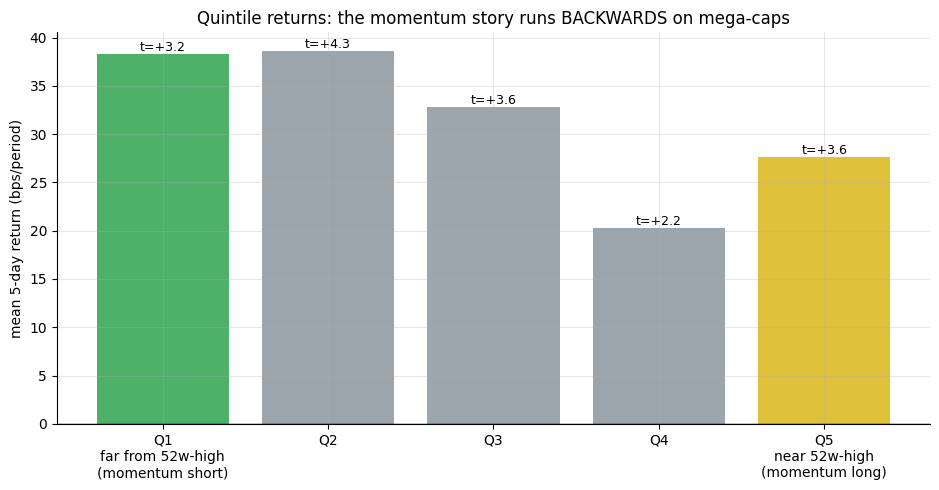

Q1 (far from high): +38.3 bps  |  Q5 (near high): +27.7 bps
Spread Q5-Q1: -10.6 bps  (negative = momentum loses)


In [2]:
if HAVE_REAL:
    panel, prox = load_real()
    fwd = st.forward_returns(panel, hold_days=5)
    q = st.quintile_backtest(prox, fwd, n_quintiles=5, rebalance_freq=5)
    q_means = [st.summarize(q[f'Q{i}'].dropna())['mean_bps'] for i in range(1, 6)]
    q_ts = [st.summarize(q[f'Q{i}'].dropna())['tstat'] for i in range(1, 6)]
else:
    q_means = [38.26, 38.61, 32.81, 20.23, 27.66]
    q_ts = [3.17, 4.3, 3.58, 2.22, 3.55]
labels = ['Q1\nfar from 52w-high\n(momentum short)', 'Q2', 'Q3', 'Q4',
          'Q5\nnear 52w-high\n(momentum long)']
colors = [GREEN if i == 0 else AMBER if i == 4 else GREY for i in range(5)]
fig, ax = plt.subplots(figsize=(9.5, 5.0))
bars = ax.bar(labels, q_means, color=colors, alpha=0.85)
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, q_ts):
    ax.annotate(f't={t:+.1f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom' if b.get_height()>=0 else 'top', fontsize=9)
ax.set_ylabel('mean 5-day return (bps/period)')
ax.set_title('Quintile returns: the momentum story runs BACKWARDS on mega-caps')
plt.tight_layout(); plt.show()
print(f'Q1 (far from high): {q_means[0]:+.1f} bps  |  Q5 (near high): {q_means[4]:+.1f} bps')
print(f'Spread Q5-Q1: {q_means[4]-q_means[0]:+.1f} bps  (negative = momentum loses)')

The momentum story runs backwards here. Q1 (farthest from the 52-week high) earns **38.3 bps** per 5-day period; Q5 (nearest to the 52-week high) earns only **27.7 bps**. The spread is **-10.6 bps** — the near-high quintile *underperforms* the far-from-high quintile on this mega-cap panel. Both quintiles earn positive returns (it's a survivorship-biased bull market sample), but the near-high names consistently lag.

Why? Within a basket of blue-chip survivors, names near their 52-week high tend to be at stretched valuations (think NVDA after a 200% run). Names far from their high are temporarily soft but fundamentally sound companies — they recover. This is the opposite of the original paper's universe, which included genuine momentum losers that stayed down.

**Does the momentum kick in at longer horizons?** The original George-Hwang paper used 6-12 month holds. Let's check if our 1-13 week window is simply too short:

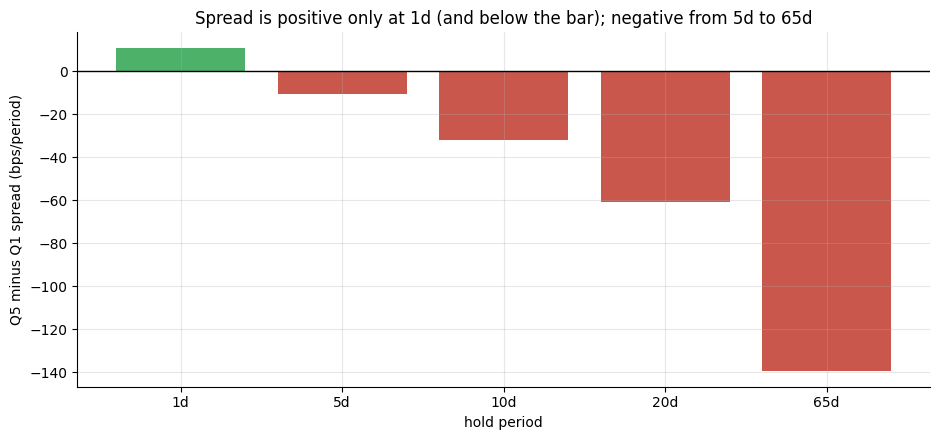

Only the 1-day horizon is positive; the signal weakens and inverts at longer holds.


In [3]:
holds = [1, 5, 10, 20, 65]
if HAVE_REAL:
    panel, prox = load_real()
    spreads = []
    for h in holds:
        fwd = st.forward_returns(panel, hold_days=h)
        q = st.quintile_backtest(prox, fwd, n_quintiles=5, rebalance_freq=5)
        s = st.summarize(q['Q5_minus_Q1'].dropna())
        spreads.append(s['mean_bps'])
else:
    spreads = [10.54, -10.6, -32.11, -60.71, -139.13]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar([str(h)+'d' for h in holds], spreads,
       color=[GREEN if s>0 else RED for s in spreads], alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold period'); ax.set_ylabel('Q5 minus Q1 spread (bps/period)')
ax.set_title('Spread is positive only at 1d (and below the bar); negative from 5d to 65d')
plt.tight_layout(); plt.show()
print('Only the 1-day horizon is positive; the signal weakens and inverts at longer holds.')

The 1-day horizon shows a small positive spread (+10.5 bps, *t* = +1.57) — consistent with the original momentum story but well below the statistical bar. At every longer horizon (5d to 65d) the spread is negative and grows more negative with time. There is no tested window where the near-high quintile significantly outperforms.

## 5 · The verdict

- **Signal — None.** The Q5-Q1 spread is **-10.6 bps/week** (HAC *t* = -0.85), negative and statistically insignificant. No hold period from 5d to 65d clears the |*t*| ≥ 2 bar, and all are in the wrong direction for the momentum thesis.
- **Tradability — Mirage.** Top decile earns only **6.8%/yr** against a passive basket at **11.3%/yr** — a 4.5 pp drag before any costs.
- **George-Hwang — Inverted on Large-Caps.** The famous anomaly does not survive intact on a 2013-2026 mega-cap panel. The survivorship-biased basket and the post-publication decay combine to eliminate the original edge at this horizon.

## 6 · Could you actually trade it?

Even if the signal were flat, the top-decile strategy lags the index before costs:

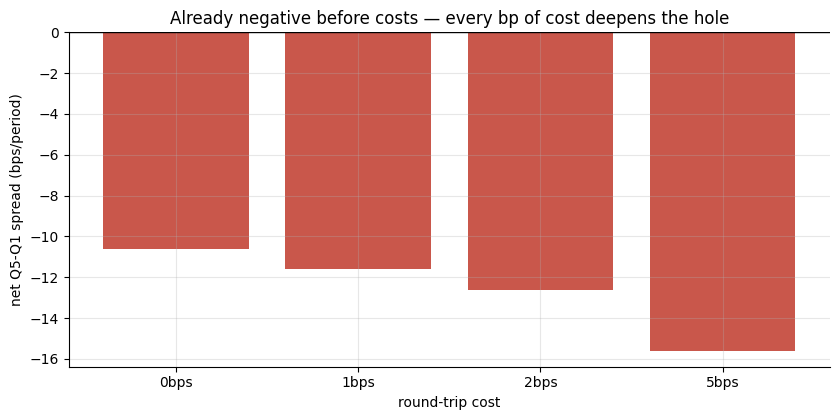

Gross spread = -10.6 bps. No transaction cost rescues it.


In [4]:
# Show the cost headwind: already negative gross at 5d, costs only dig deeper
costs = [0.0, 1.0, 2.0, 5.0]
gross_spread = R['spread_mean']   # Q5-Q1 at 5d
net = [gross_spread - c for c in costs]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f'{c:.0f}bps' for c in costs], net,
       color=[RED]*len(net), alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost'); ax.set_ylabel('net Q5-Q1 spread (bps/period)')
ax.set_title('Already negative before costs — every bp of cost deepens the hole')
plt.tight_layout(); plt.show()
print(f'Gross spread = {gross_spread:+.1f} bps. No transaction cost rescues it.')

The gross spread is already negative at 5d, so there is **no transaction cost low enough** to make the strategy work. The top-decile version also requires weekly rebalancing in large-cap names — not costly, but with a strategy that already trails the index, every round-trip compounds the drag.

## 7 · Going further

- **The original sample matters.** George & Hwang (2004) used CRSP 1963-2001 with thousands of stocks including true momentum losers. That universe is very different from 20 mega-cap survivors. A broader, unbiased test over the original period would be a better replication.
- **Longer hold periods.** The original paper found the effect strongest at 6-12 months. Our 1-65 day window may simply be too short to capture the anchoring dynamic.
- **The contrarian mirror.** Study 202 tests stocks near their 52-week *low* as a contrarian bet — also a non-result on the same sample, consistent with mild mean-reversion within this elite basket.
- **Turtle Trading (Study 103).** Uses the 52-week range for breakout entry decisions rather than a cross-sectional rank — a related but mechanically different approach that did find a real signal.

*The fair test of George-Hwang on modern data requires an unbiased universe, the original 6-12 month holding period, and a fresh out-of-sample window from 2001 onward. That is a project for a future study.*